Before running the tutorial, make sure you downloaded the u2os_merfish.h5ad file from https://doi.org/10.6084/m9.figshare.c.6564043.

In [1]:
import numpy as np
import scanpy as sc
from anndata import AnnData
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

import pytrance as pt

RANDOM_SEED = 808

/home/lstreng/miniforge3/envs/pytrance/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parameter choices always depend on the dataset:  
In general, we recommend to set a threshold for minimum gene and cell counts to remove lowly expressed genes and low quality cells. In this dataset all genes are highly expressed (compared to other datasets) and cells have high counts, so we don't set a threshold for either. When analyzing your own data you can infer thresholds for example from gene or cell count histogram plots.

When using a radius-based graph construction, the radius should be chosen depending on the average cell size and spatial scale of interest. When using a nearest neighbor-based construction the number of neighbors should be based on transcript density.

For faster processing we only use a small subset of the data here.


In [2]:
# raw data params
batches = [0, 1, 2] # list of batches or 'all'
min_gene_counts = 0
min_cell_counts = 0

# data prep params
radius = 50
n_neighbors = 0
n_jobs = 10
edges = 'connectivity'
include_self = True

cell_key = 'cell'
gene_key = 'gene'
x_key = 'x'
y_key = 'y'
z_key = None

### 1. prepare data for training and analysis

The data has to be in anndata format with observations corresponding to single transcripts.

In [3]:
adata_cellular = sc.read_h5ad('data/u2os_merfish.h5ad')

# subset and filter data
if type(batches) is str:
    batch_list_str = adata_cellular.obs['batch'].unique()
    batch_list_int = [int(b) for b in batch_list_str]
else:
    batch_list_int = batches
    batch_list_str = [str(b) for b in batches]
    
adata_cellular_filtered = adata_cellular[adata_cellular.obs['batch'].isin(batch_list_str)].copy()
adata_cellular_filtered.uns['points'] = adata_cellular_filtered.uns['points'][adata_cellular_filtered.uns['points']['batch'].isin(batch_list_int)].copy()

# make one hot encoded matrix for transcripts
genes_one_hot = OneHotEncoder().fit(np.sort(adata_cellular_filtered.uns['points'][gene_key].unique()).reshape(-1, 1)).transform(adata_cellular_filtered.uns['points'][gene_key].values.reshape(-1, 1))

# create anndata object from dataframe
adata_cellular_filtered.uns['points'].index = adata_cellular_filtered.uns['points'].index.astype(str) # avoid warning
adata = AnnData(genes_one_hot,
                obs = adata_cellular_filtered.uns['points'])
adata.obsm['spatial'] = np.stack((adata.obs[x_key].values, adata.obs[y_key].values), axis=1)
adata.var.index = np.sort(adata.obs[gene_key].unique())

del genes_one_hot

# filter by gene count
genes_to_keep = adata.var_names[np.asarray(adata.X.sum(axis=0))[0] > min_gene_counts]
adata = adata[adata.obs[gene_key].isin(genes_to_keep), genes_to_keep].copy()
#filter by cell counts
cell_counts = adata.obs[cell_key].value_counts()
cells_to_keep = cell_counts.index[(cell_counts > max(min_cell_counts, n_neighbors))]
adata = adata[adata.obs[cell_key].isin(cells_to_keep)].copy()
adata.obs = adata.obs.reset_index(drop=True)

le = LabelEncoder()
le.fit(adata.obs[cell_key].values)
adata.obs['cell_encoded'] = le.transform(adata.obs[cell_key].values) # add integer cell IDs

adata.obs['id'] = np.arange(adata.n_obs)

print(adata)
print('median transcripts per cell:', np.median(adata.obs.groupby(cell_key, observed=True).count().iloc[:, 0].values))
print('mean transcripts per cell:', np.mean(adata.obs.groupby(cell_key, observed=True).count().iloc[:, 0].values))

/home/lstreng/miniforge3/envs/pytrance/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 664116 × 135
    obs: 'x', 'y', 'gene', 'cell', 'nucleus', 'batch', 'cell_encoded', 'id'
    obsm: 'spatial'
median transcripts per cell: 13935.5
mean transcripts per cell: 13835.75


In [4]:
# load cell and nucleus boundaries
# helper function from https://gis.stackexchange.com/questions/359962/shapely-wkt-loads-skip-bad-geometries
from shapely import wkt
def wkt_loads(x):
    try:
        return wkt.loads(x)
    except Exception:
        return None

boundary_coords = [np.array(wkt_loads(cs).boundary.coords) for cs in adata_cellular.obs.cell_shape]
cell_boundaries = pd.DataFrame({'x': [bc[:, 0] for bc in boundary_coords], 'y': [bc[:, 1] for bc in boundary_coords]}, index=adata_cellular.obs_names)

boundary_coords = [np.array(wkt_loads(ns).boundary.coords) if ns != 'None' else np.array([[None, None]]) for ns in adata_cellular.obs.nucleus_shape]
nucleus_boundaries = pd.DataFrame({'x': [bc[:, 0] for bc in boundary_coords], 'y': [bc[:, 1] for bc in boundary_coords]}, index=adata_cellular.obs_names)

### 2. create model and training data

In [5]:
from pytrance.models.DGI.models import DGI
from torch.optim import Adam
from torch_geometric.loader import DataLoader

In [6]:
# model params
hid_units = [16]

# train params
epochs = 10
batch_size = 1
patience = 20
lr = 0.001
l2_coef = 0.0
drop_prob = 0.0
device = 'cuda'
minibatching = True

In [7]:
ft_size = adata.n_vars

# create model and load to GPU
model = DGI(ft_size, hid_units)
optimiser = Adam(model.parameters(), lr=lr, weight_decay=l2_coef)

if device == 'cuda':
    model.cuda()

In [8]:
# set up torch data loader
print('preparing data loader ... ')
graph_kwargs = {
    'radius': radius,
    'n_neighbors': n_neighbors,
    'x_key': x_key,
    'y_key': y_key,
    'z_key': None,
    'mode': edges,
    'n_jobs': n_jobs,
    'include_self': include_self
    }

cell_indices = adata.obs.groupby(cell_key).indices
data = pt.data.CellData(adata, cell_indices, graph_kwargs, seed=RANDOM_SEED)
train_loader = DataLoader(data, batch_size=batch_size)

/tmp/ipykernel_2848405/3924042032.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_indices = adata.obs.groupby(cell_key).indices


preparing data loader ... 
setting up torch data set ...


100%|██████████| 48/48 [00:11<00:00,  4.19it/s]


### 3. train model

In [9]:
# train GNN
embeds_shape = (adata.n_obs, hid_units[-1])
pt.gnn.train(model,
             train_loader,
             optimiser,
             device,
             embeds_shape,
             epochs,
             save_steps=None)

embeds = pt.gnn.compute_embeddings(model, train_loader, embeds_shape)

Save results to: /data/rajewsky/home/lstreng/pyTrance/docs/tutorials/


Epoch: 0	train loss: 0.6282734141465556	passed time: 126.0s


Epoch: 1	train loss: 0.5567959273101437	passed time: 126.0s


Epoch: 2	train loss: 0.49391883019263927	passed time: 127.0s


Epoch: 3	train loss: 0.43270422288492427	passed time: 127.0s


...

Epoch: 5	train loss: 0.32953880590327583	passed time: 129.0s


Epoch: 6	train loss: 0.2938799153519791	passed time: 127.0s


Epoch: 7	train loss: 0.265246765660542	passed time: 127.0s


Epoch: 8	train loss: 0.2425448825359305	passed time: 127.0s


Epoch: 9	train loss: 0.2242569216199069	passed time: 127.0s
saving embeddings ... 


### 4. aggregate and cluster embeddings

In [ ]:
# load pre-computed embeddings
#embeds = np.load('embeds.npz')['a']

In [10]:
# aggregate transcript embeddings per gene
embeds_aggregated = pt.tl.aggregate_transcript_embeddings(embeds, adata)

# PCA on gene embeddings
embeds_pca, pca_model = pt.tl.embedding_pca(embeds_aggregated, seed=RANDOM_SEED)

100%|██████████| 135/135 [00:00<00:00, 1711.36it/s]


If you know the number of subcellular patterns to expect in your data, a clustering algorithm that allows to set the number of clusters manually (e.g., k-means) is probably the easiest approach to use. However, we made the experience that a manually fine tuned leiden clustering can lead to even better results, so it might be worth exploring both.  

In [11]:
# kmeans clustering
pt.tl.cluster_gene_embeddings(
    embeds = embeds_aggregated,
    n_clusters = 5,
    adata = adata,
    algo = 'kmeans',
    return_labels = False,
    seed = RANDOM_SEED)

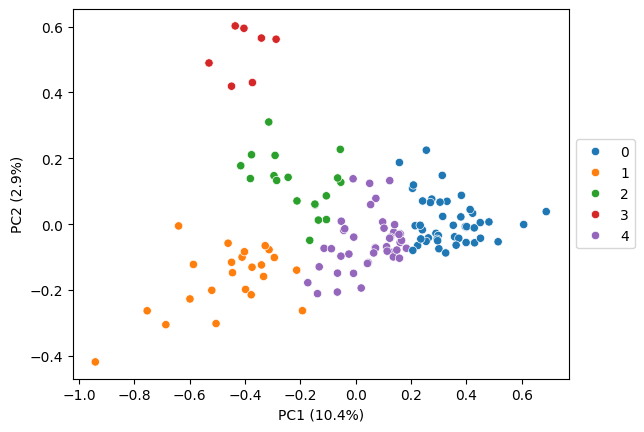

In [12]:
pt.pl.embedding_pca(adata, embeds_pca, key='kmeans', pca_model=pca_model, palette='tab10')

For leiden fine tuning, we recommend to start with the default resolution and iteratively refine it by first exploring the localization patterns visually (step 5). If multiple clusters show the same pattern you might want to decrease the resolution for a more coarse clustering. Additionally, you can look for subclusters in the embedding heatmap (step 7), which indicates that the initial clustering is too coarse.  
In our experience, clusters often correspond to cell compartments in which the RNAs co-localize, such as nucleus, nuclear edge, cytoplasm, cell edge. Therefore, aiming for 4-6 clusters is usually a good starting point.

/home/lstreng/miniforge3/envs/pytrance/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


detected 8 clusters


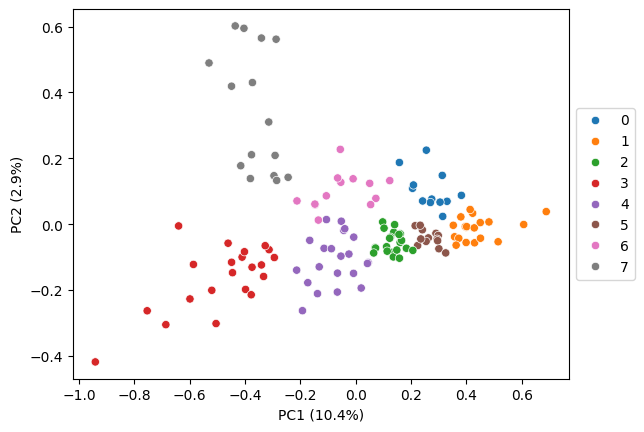

In [13]:
# leiden clustering, default resolution (too granular)
pt.tl.cluster_gene_embeddings_leiden(
    embeds = embeds_aggregated,
    n_neighbors = 10,
    adata = adata,
    return_labels = False,
    key_added='leiden_default',
    seed = RANDOM_SEED)

pt.pl.embedding_pca(adata, embeds_pca, key='leiden_default', pca_model=pca_model, palette='tab10')

detected 5 clusters


/home/lstreng/miniforge3/envs/pytrance/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


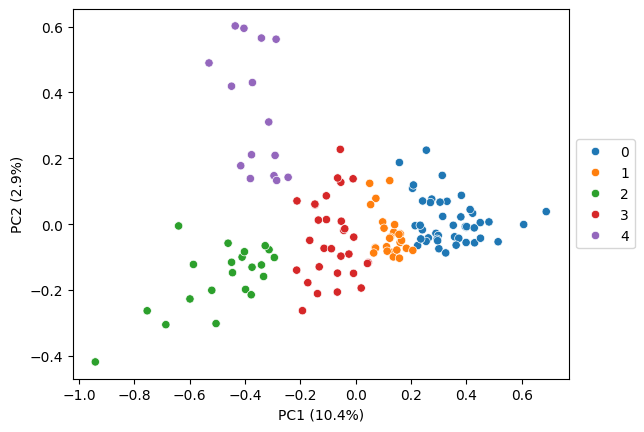

In [14]:
# leiden clustering, fine tuned
pt.tl.cluster_gene_embeddings_leiden(
    embeds = embeds_aggregated,
    resolution = 0.5,
    n_neighbors = 10,
    adata = adata,
    return_labels = False,
    key_added='leiden_ft',
    seed = RANDOM_SEED)

pt.pl.embedding_pca(adata, embeds_pca, key='leiden_ft', pca_model=pca_model, palette='tab10')

### 5. explore clusters visually

In [15]:
cluster = 2
clustering_algo = 'leiden_ft'
gene_set = adata.var_names[adata.var[clustering_algo] == cluster]

# sample random cells
n_cells = 4
rng = np.random.default_rng(RANDOM_SEED)
random_cells = rng.choice(adata.obs[cell_key].unique().tolist(), n_cells)

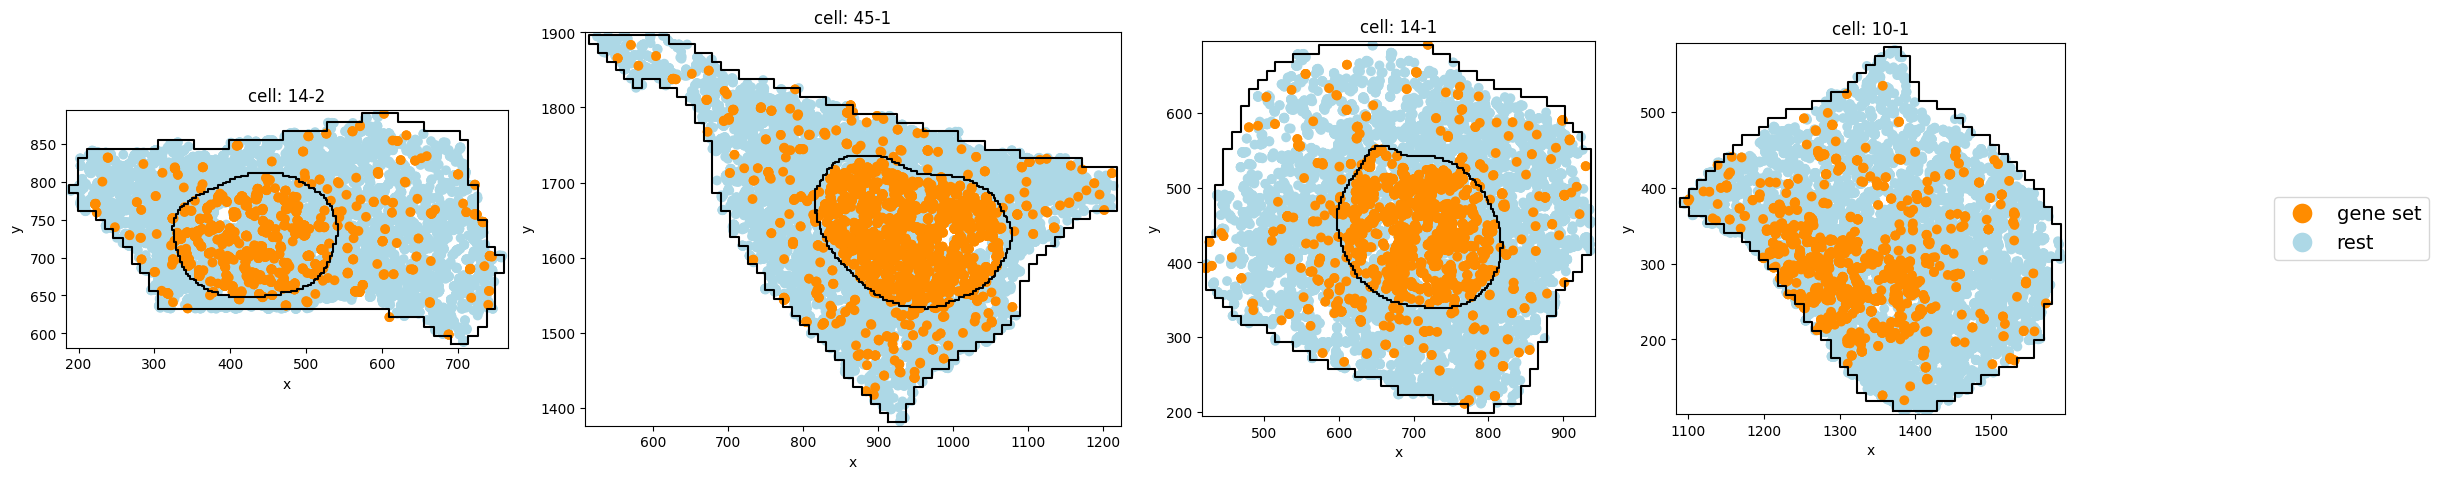

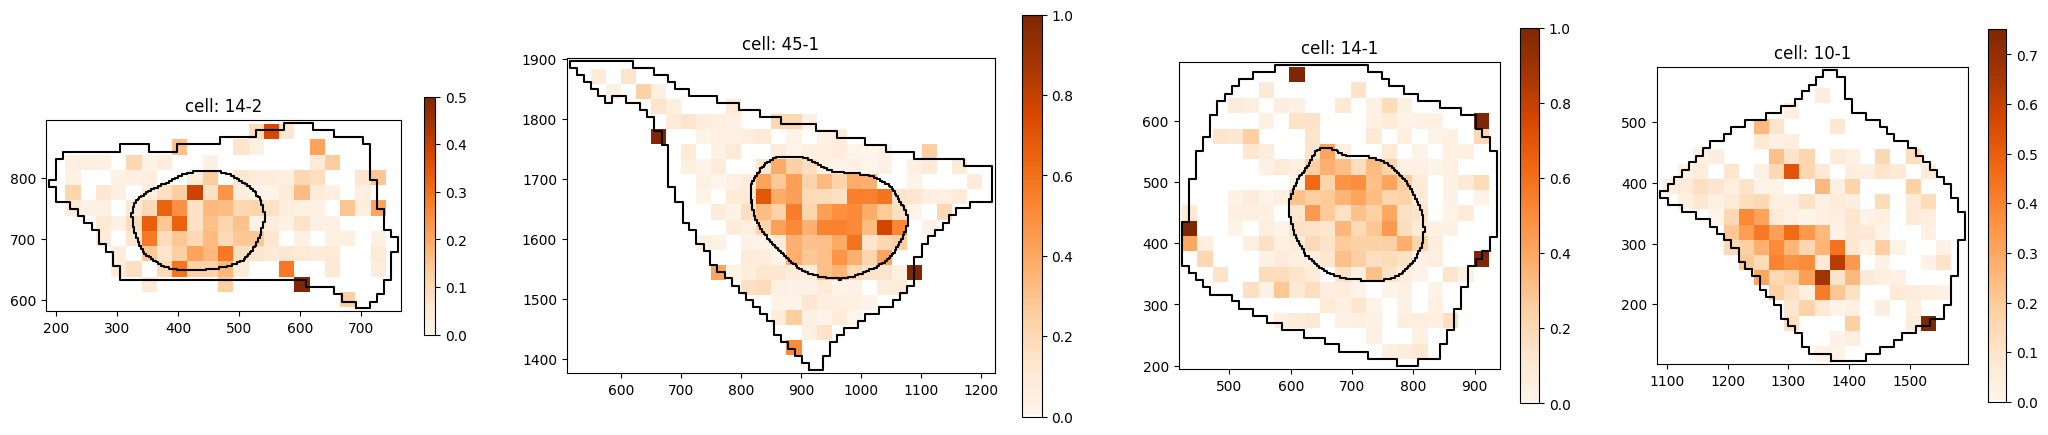

In [16]:
# plot distribution of single transcripts
pt.pl.cells_in_grid(1,
                    4,
                    adata,
                    genes=gene_set,
                    cell_list=random_cells,
                    cell_boundaries=cell_boundaries,
                    nucleus_boundaries=nucleus_boundaries,
                    hue='gene set',
                    plot_type='scatter',
                    )
    
# plot transcript density of gene set
pt.pl.cells_in_grid(1,
                    4,
                    adata,
                    genes=gene_set,
                    cell_list=random_cells,
                    cell_boundaries=cell_boundaries,
                    nucleus_boundaries=nucleus_boundaries,
                    hue='gene set',
                    plot_type='histogram_relative',
                    )

### 6. compute CLQ scores

Computing CLQs for gene set:
['AGO3', 'ARL10', 'BUB3', 'FZD5', 'MALAT1', 'MCF2L', 'NKTR', 'POLQ', 'RAD51D', 'RNF152', 'RP4-671O14.6', 'SKP1', 'SLC5A3', 'SOD2', 'STARD9', 'TMOD2', 'TSPAN3', 'UMPS', 'XKR5', 'YIPF4', 'ZBTB43']


cells: 100%|██████████| 9/9 [00:20<00:00,  2.28s/it]


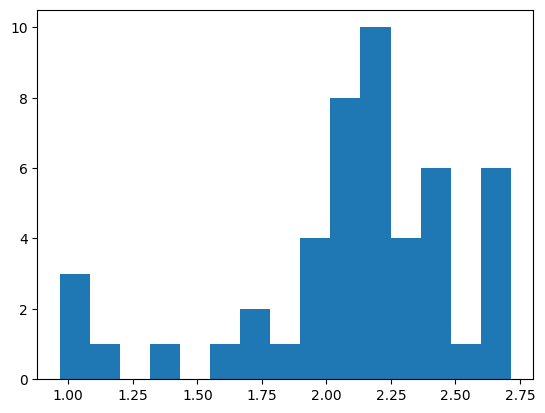

In [20]:
gene_set = adata.var[adata.var[clustering_algo] == cluster].index.tolist()

print(f'Computing CLQs for gene set:\n{gene_set}')
clqs, clqs_adjusted, clqs_permuted = pt.cell_score.clq(adata,
                                                       genes=gene_set,
                                                       graph=None,
                                                       n_neighbors=n_neighbors,
                                                       radius=radius,
                                                       n_permutations=100,
                                                       seed=RANDOM_SEED, 
                                                       use_obs=True,
                                                       n_processes=5,
                                                       z_key=None
                                                       )

plt.hist(clqs_adjusted.values(), bins=15)
plt.show()

### 7. subclustering

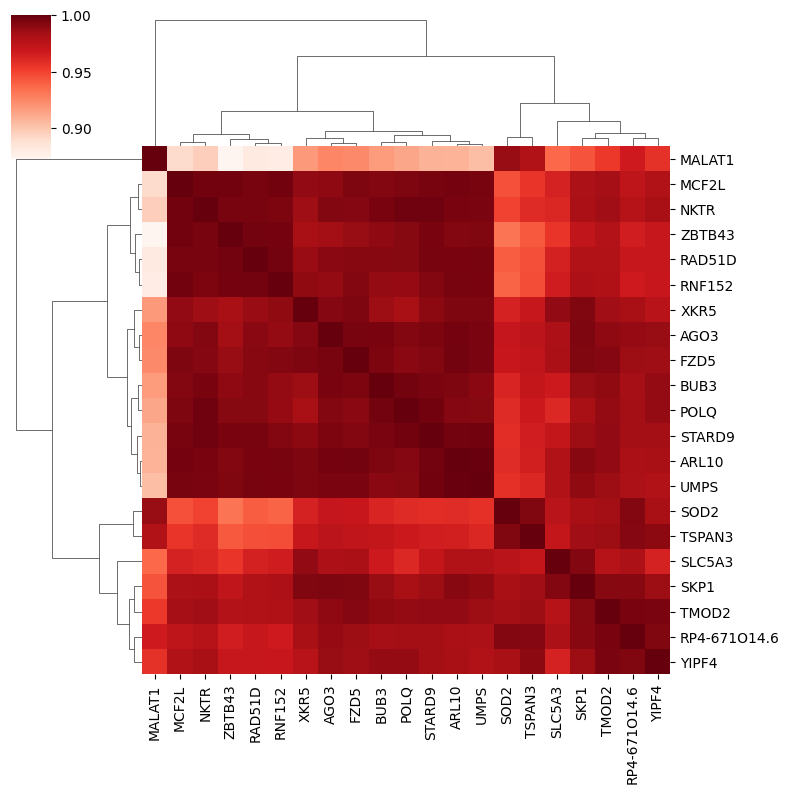

In [21]:
corr_pd_cluster = embeds_aggregated.loc[adata.var[clustering_algo] == cluster].T.corr()

clustermap = sns.clustermap(corr_pd_cluster, method='ward', figsize=(8, 8), cmap='Reds')
plt.show()

The subclusters can be visually inferred from the heatmap above. To determine the `distance_threshold` that produces the desired subclusters it's easiest to run the subclustering once with default parameters and take the threshold from the y-axis of the resulting plot. Alternatively you can also define a number of subclusters using the `n_subclusters` parameter.  
Here, the subcluster on the right could potentially be split even further.

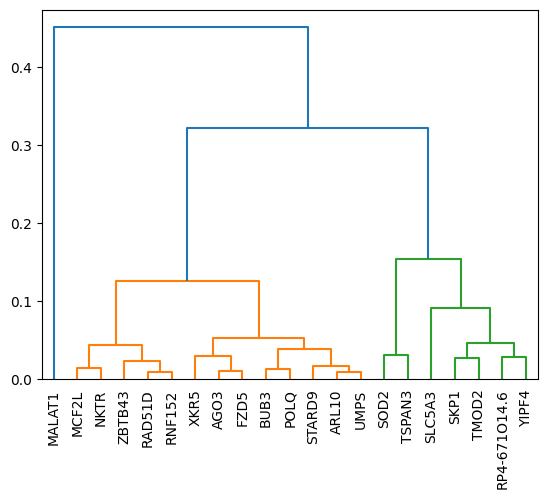

{0: ['RP4-671O14.6', 'SKP1', 'SLC5A3', 'SOD2', 'TMOD2', 'TSPAN3', 'YIPF4'],
 1: ['MALAT1'],
 2: ['AGO3',
  'ARL10',
  'BUB3',
  'FZD5',
  'MCF2L',
  'NKTR',
  'POLQ',
  'RAD51D',
  'RNF152',
  'STARD9',
  'UMPS',
  'XKR5',
  'ZBTB43']}

In [ ]:
gene_set = adata.var[adata.var[clustering_algo] == cluster].index.tolist()
gene_names_ordered = [label.get_text() for label in clustermap.ax_heatmap.get_xmajorticklabels()]

cluster_gene_sets_subset = pt.tl.subcluster(corr_pd_cluster.to_numpy(),
                                            genes=gene_set,
                                            distance_threshold=0.2,
                                            plot_tree=True,
                                            gene_names_ordered=gene_names_ordered)
cluster_gene_sets_subset

Subcluster with weak nuclear localization:

In [23]:
subcluster = 2
gene_subset = cluster_gene_sets_subset[subcluster]

# sample random cells
n_cells = 4
rng = np.random.default_rng(RANDOM_SEED)
random_cells = rng.choice(adata.obs[cell_key].unique().tolist(), n_cells)

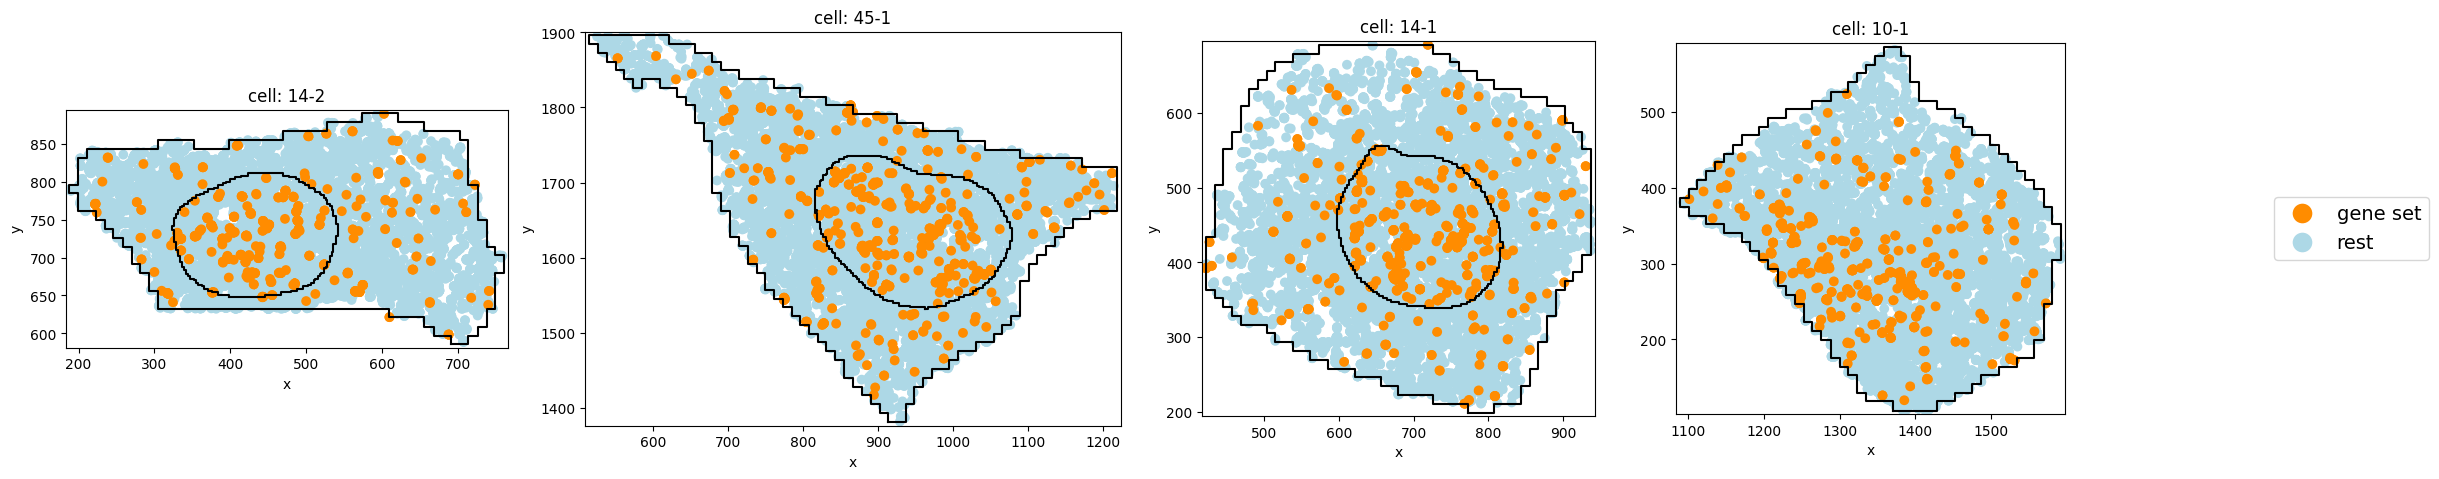

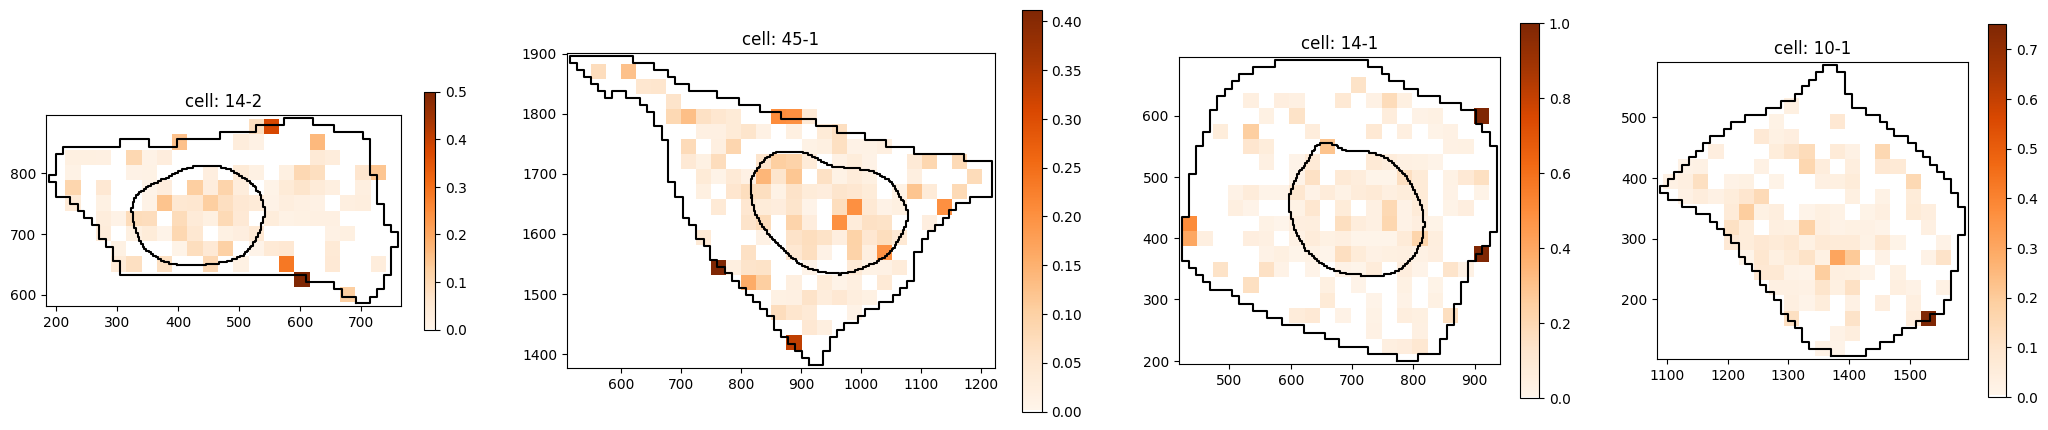

In [ ]:
# plot distribution of single transcripts
pt.pl.cells_in_grid(1,
                    4,
                    adata,
                    genes=gene_subset,
                    cell_list=random_cells,
                    cell_boundaries=cell_boundaries,
                    nucleus_boundaries=nucleus_boundaries,
                    hue='gene set',
                    plot_type='scatter',
                    )

# plot transcript density of gene set
pt.pl.cells_in_grid(1,
                    4,
                    adata,
                    genes=gene_subset,
                    cell_list=random_cells,
                    cell_boundaries=cell_boundaries,
                    nucleus_boundaries=nucleus_boundaries,
                    hue='gene set',
                    plot_type='histogram_relative',
                    )

Computing CLQs for gene set:
['AGO3', 'ARL10', 'BUB3', 'FZD5', 'MCF2L', 'NKTR', 'POLQ', 'RAD51D', 'RNF152', 'STARD9', 'UMPS', 'XKR5', 'ZBTB43']


cells: 100%|██████████| 9/9 [00:08<00:00,  1.07it/s]


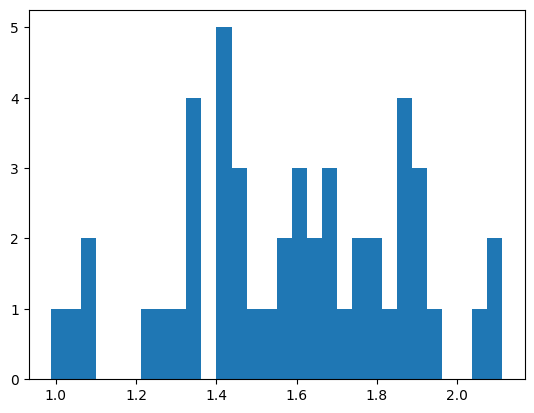

In [25]:
# compute CLQs for each cluster for random cells
gene_subset = cluster_gene_sets_subset[subcluster]

print(f'Computing CLQs for gene set:\n{gene_subset}')
clqs, clqs_adjusted, clqs_permuted = pt.cell_score.clq(adata,
                                                       genes=gene_subset,
                                                       graph=None,
                                                       n_neighbors=n_neighbors,
                                                       radius=radius,
                                                       n_permutations=100,
                                                       seed=RANDOM_SEED, 
                                                       use_obs=True,
                                                       n_processes=5,
                                                       z_key=None
                                                       )

plt.hist(clqs_adjusted.values(), bins=30)
plt.show()

Subcluster with stronger nuclear localization:

In [29]:
subcluster = 0
gene_subset = cluster_gene_sets_subset[subcluster]

# sample random cells
n_cells = 4
rng = np.random.default_rng(RANDOM_SEED)
random_cells = rng.choice(adata.obs[cell_key].unique().tolist(), n_cells)

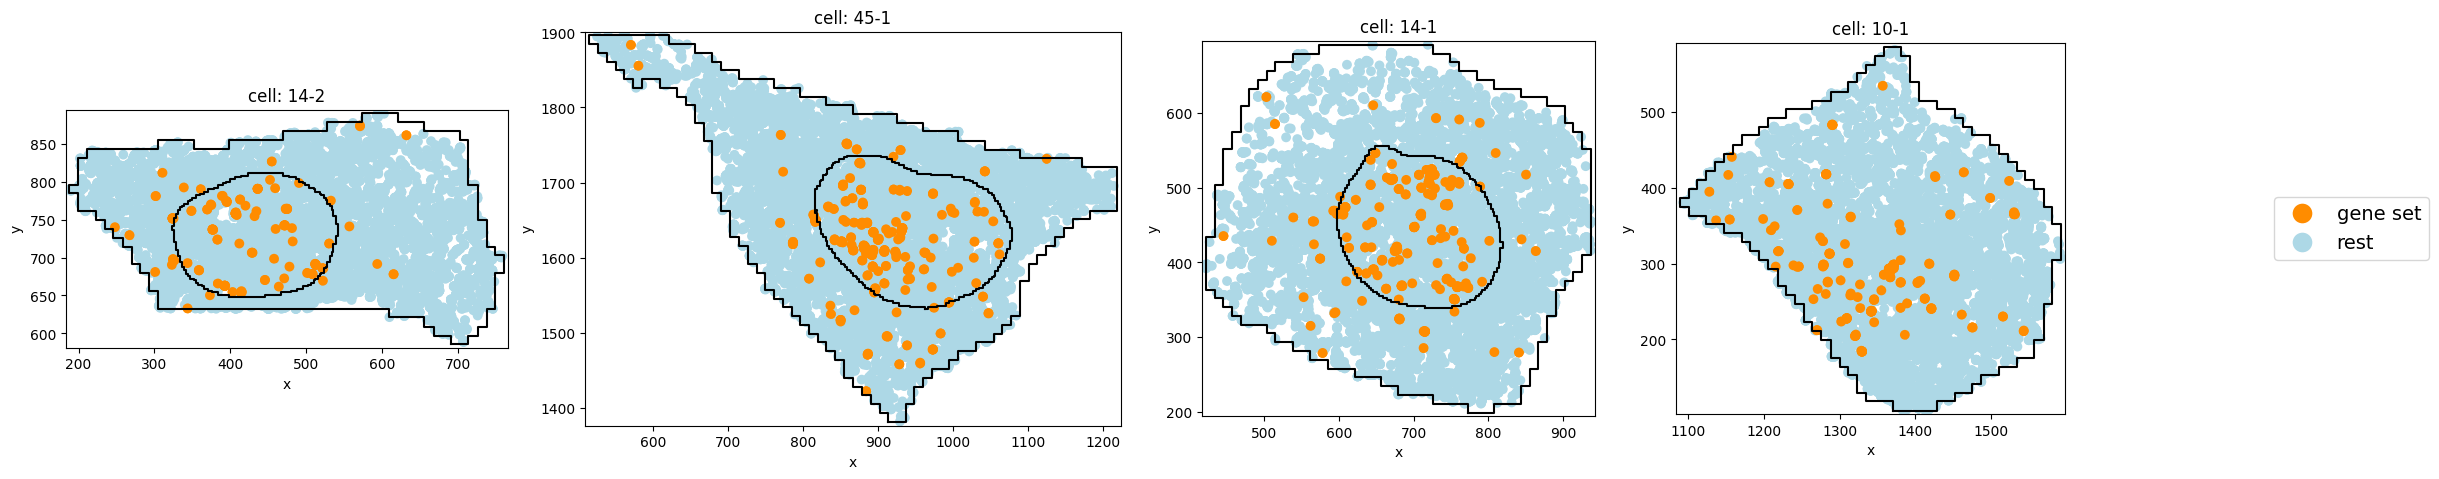

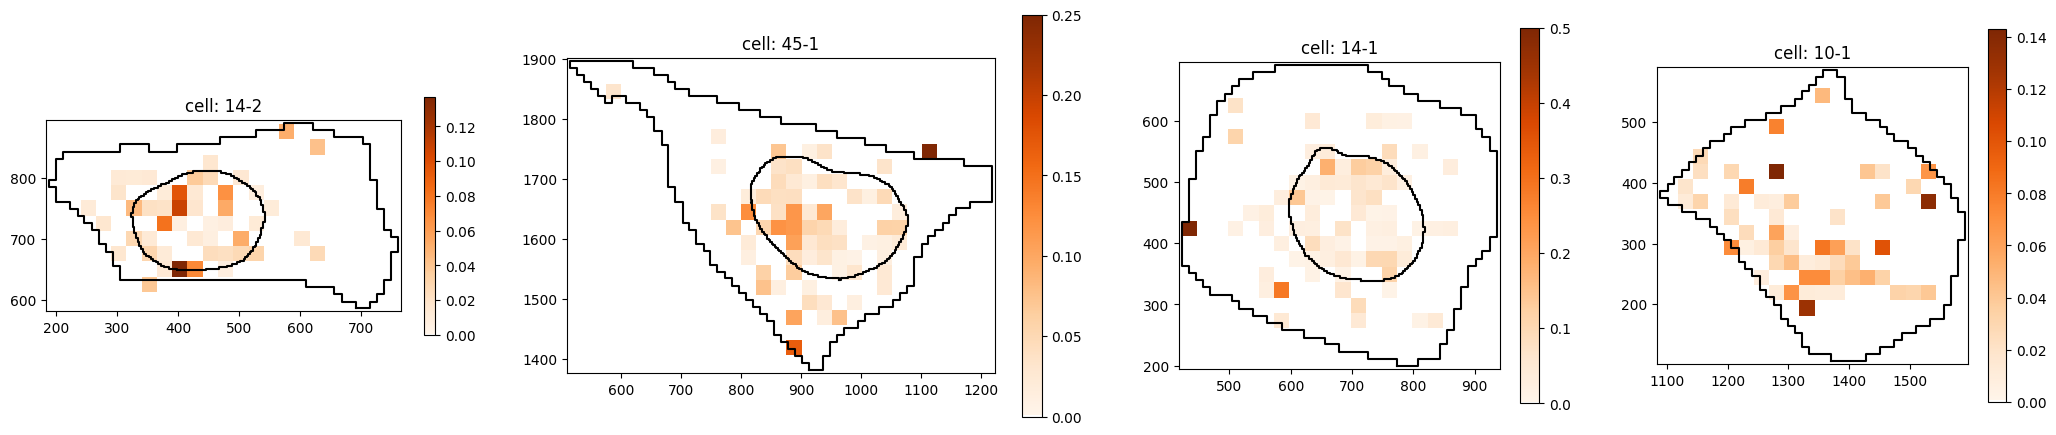

In [30]:
# plot distribution of single transcripts
pt.pl.cells_in_grid(1,
                    4,
                    adata,
                    genes=gene_subset,
                    cell_list=random_cells,
                    cell_boundaries=cell_boundaries,
                    nucleus_boundaries=nucleus_boundaries,
                    hue='gene set',
                    plot_type='scatter',
                    )

# plot transcript density of gene set
pt.pl.cells_in_grid(1,
                    4,
                    adata,
                    genes=gene_subset,
                    cell_list=random_cells,
                    cell_boundaries=cell_boundaries,
                    nucleus_boundaries=nucleus_boundaries,
                    hue='gene set',
                    plot_type='histogram_relative',
                    )

Computing CLQs for gene set:
['RP4-671O14.6', 'SKP1', 'SLC5A3', 'SOD2', 'TMOD2', 'TSPAN3', 'YIPF4']


cells: 100%|██████████| 9/9 [00:06<00:00,  1.43it/s]


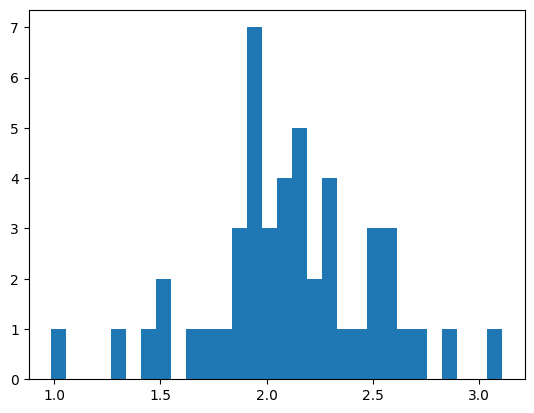

In [31]:
# compute CLQs for each cluster for random cells
gene_subset = cluster_gene_sets_subset[subcluster]

print(f'Computing CLQs for gene set:\n{gene_subset}')
clqs, clqs_adjusted, clqs_permuted = pt.cell_score.clq(adata,
                                                       genes=gene_subset,
                                                       graph=None,
                                                       n_neighbors=n_neighbors,
                                                       radius=radius,
                                                       n_permutations=100,
                                                       seed=RANDOM_SEED, 
                                                       use_obs=True,
                                                       n_processes=5,
                                                       z_key=None
                                                       )

plt.hist(clqs_adjusted.values(), bins=30)
plt.show()